# Pythia Attention Sink: Position 0 vs Positions 1, 2, and 3

This notebook compares how much attention later tokens assign to the **first four token positions individually**:

- Position 0
- Position 1
- Position 2
- Position 3

The goal is to answer:

> Is the attention sink mostly concentrated at position 0, or is attention distributed across the first several positions?

The notebook uses `EleutherAI/pythia-160m` in **FP32** for numerical stability.

## 1. Install dependencies

In [1]:
!pip -q install -U transformers accelerate matplotlib pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 62.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 59.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 63.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.3, but you have pandas 3.0.6 which is incompatible.
cudf-cu13 26.6.0 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.6 which is incompatible.
dask-cudf-cu13 26.6.0 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.6 which is incompatible.


## 2. Imports and settings

In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from transformers import AutoTokenizer, AutoModelForCausalLM

MODEL_NAME = "EleutherAI/pythia-160m"
MAX_TOKENS = 192
QUERY_START = 16
EARLY_POSITIONS = [0, 1, 2, 3]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = False

try:
    torch.set_float32_matmul_precision("highest")
except Exception:
    pass

print("Device:", device)
print("PyTorch:", torch.__version__)

Device: cuda
PyTorch: 2.11.0+cu130


## 3. Load Pythia in FP32

In [2]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float32,
    attn_implementation="eager",
)

model = model.to(device)
model.eval()

first_param = next(model.parameters())

print("Loaded:", MODEL_NAME)
print("Parameter dtype:", first_param.dtype)
print("Layers:", model.config.num_hidden_layers)
print("Attention heads:", model.config.num_attention_heads)
print("Hidden size:", model.config.hidden_size)

assert first_param.dtype == torch.float32

config.json:   0%|          | 0.00/569 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/396 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.11M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors: reconstructing file:   0%|          |  0.00B /  375MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loaded: EleutherAI/pythia-160m
Parameter dtype: torch.float32
Layers: 12
Attention heads: 12
Hidden size: 768


## 4. Build a long test prompt

We prepend Pythia's EOS token so that position 0 is a clear special initial token.

In [3]:
base_text = '''
Artificial intelligence systems process sequences using transformer networks.
Self-attention allows each token to compare query representations against key
representations from earlier tokens. In causal language models, future positions
are masked. During long-context inference, some early positions can receive
unexpectedly large amounts of attention from many later tokens. These positions
are often called attention sinks.
'''

special = tokenizer.eos_token if tokenizer.eos_token is not None else ""
prompt = special + "\n" + (base_text + "\n") * 10

encoded = tokenizer(
    prompt,
    return_tensors="pt",
    truncation=True,
    max_length=MAX_TOKENS,
    add_special_tokens=False,
)

input_ids = encoded["input_ids"].to(device)
attention_mask = encoded["attention_mask"].to(device)

tokens = tokenizer.convert_ids_to_tokens(input_ids[0].tolist())
T = input_ids.shape[1]

print("Sequence length:", T)
print("First 12 tokens:")
for i, tok in enumerate(tokens[:12]):
    print(i, repr(tok))

Sequence length: 192
First 12 tokens:
0 '<|endoftext|>'
1 'Ċ'
2 'Ċ'
3 'Art'
4 'ificial'
5 'Ġintelligence'
6 'Ġsystems'
7 'Ġprocess'
8 'Ġsequences'
9 'Ġusing'
10 'Ġtransformer'
11 'Ġnetworks'


## 5. Forward pass and collect attention matrices

In [4]:
with torch.inference_mode():
    if device.type == "cuda":
        with torch.autocast(device_type="cuda", enabled=False):
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                output_attentions=True,
                use_cache=False,
                return_dict=True,
            )
    else:
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_attentions=True,
            use_cache=False,
            return_dict=True,
        )

attentions = outputs.attentions

print("Number of layers:", len(attentions))
print("One attention tensor shape:", attentions[0].shape)
print("Attention dtype:", attentions[0].dtype)

Number of layers: 12
One attention tensor shape: torch.Size([1, 12, 192, 192])
Attention dtype: torch.float32


## 6. Check for NaN / Inf

In [6]:
health = []

for layer_idx, attn in enumerate(attentions):
    a = attn.detach().float()

    health.append({
        "layer": layer_idx,
        "has_nan": bool(torch.isnan(a).any().item()),
        "has_inf": bool(torch.isinf(a).any().item()),
        "finite": bool(torch.isfinite(a).all().item()),
    })

health_df = pd.DataFrame(health)
display(health_df)

if not health_df["finite"].all():
    bad = health_df.loc[~health_df["finite"], "layer"].tolist()
    raise RuntimeError(
        f"Non-finite attention found in layer(s): {bad}. "
        "Restart runtime and make sure the model is loaded in FP32."
    )

print("All attention tensors are finite.")

,layer,has_nan,has_inf,finite
0,0,False,False,True
1,1,False,False,True
2,2,False,False,True
3,3,False,False,True
4,4,False,False,True
5,5,False,False,True
6,6,False,False,True
7,7,False,False,True
8,8,False,False,True
9,9,False,False,True


All attention tensors are finite.


## 7. Stack attention tensors

In [7]:
attn_stack = torch.stack(
    [a[0].detach().float().cpu() for a in attentions],
    dim=0
)

# Shape: [layers, heads, query_position, key_position]
L, H, T, _ = attn_stack.shape

print("Stack shape:", attn_stack.shape)

Stack shape: torch.Size([12, 12, 192, 192])


## 8. Compute attention to positions 0, 1, 2, and 3 by layer

For each layer and each early key position \(j\), we compute:

\[
S_{l,j}
=
\frac{1}{H(T-q_0)}
\sum_h
\sum_{i=q_0}^{T-1}
A^{(l,h)}_{i,j}
\]

where `q0 = QUERY_START`.

So each value answers:

> On average, how much attention do later query tokens assign to this specific early position?

In [8]:
# Select:
# all layers
# all heads
# later query positions
# key positions 0,1,2,3
early_attention = attn_stack[:, :, QUERY_START:, EARLY_POSITIONS]

# Average over heads and later query positions
# Result shape: [layers, 4]
layer_position_scores = early_attention.mean(dim=(1, 2))

print("Layer-position score shape:", layer_position_scores.shape)

Layer-position score shape: torch.Size([12, 4])


## 9. Main plot: position 0 vs positions 1, 2, and 3 across layers

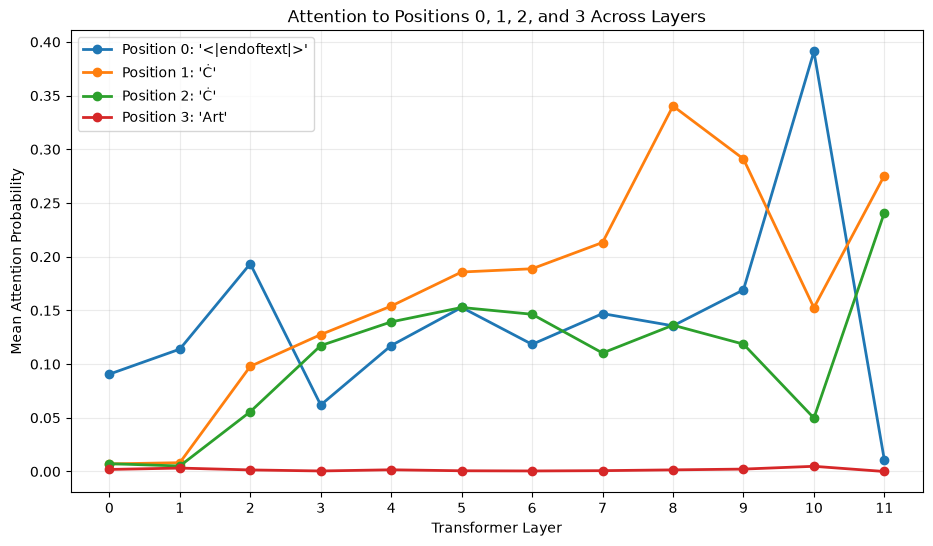

In [9]:
scores = layer_position_scores.numpy()

plt.figure(figsize=(11, 6))

for idx, pos in enumerate(EARLY_POSITIONS):
    plt.plot(
        np.arange(L),
        scores[:, idx],
        marker="o",
        linewidth=2,
        label=f"Position {pos}: {tokens[pos]!r}"
    )

plt.xlabel("Transformer Layer")
plt.ylabel("Mean Attention Probability")
plt.title("Attention to Positions 0, 1, 2, and 3 Across Layers")
plt.xticks(np.arange(L))
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## 10. Grouped bar chart

This makes layer-by-layer comparison easier.

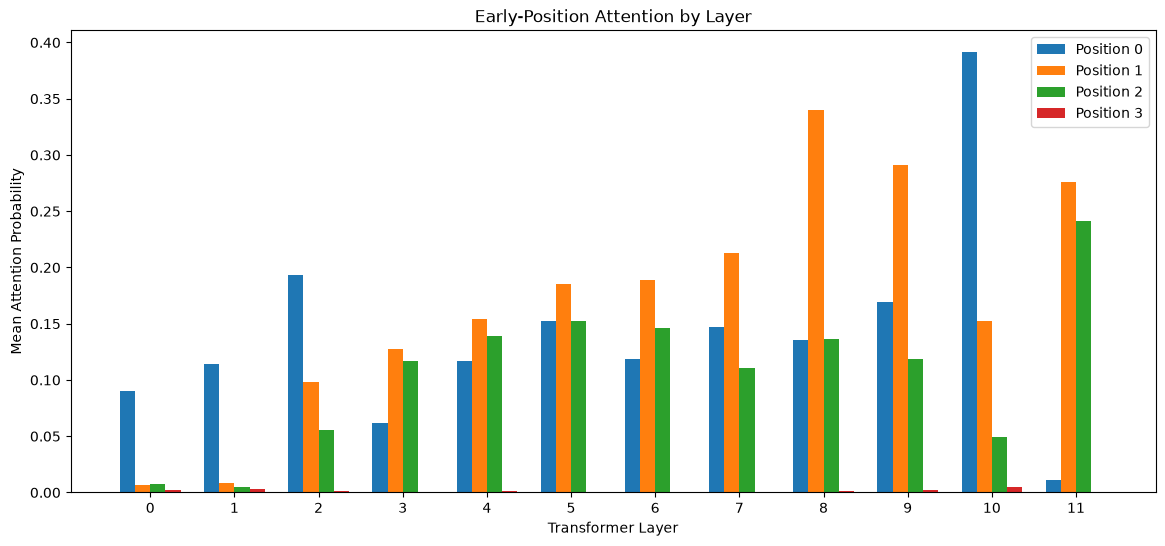

In [10]:
x = np.arange(L)
width = 0.18

plt.figure(figsize=(14, 6))

for idx, pos in enumerate(EARLY_POSITIONS):
    offset = (idx - 1.5) * width
    plt.bar(
        x + offset,
        scores[:, idx],
        width=width,
        label=f"Position {pos}"
    )

plt.xlabel("Transformer Layer")
plt.ylabel("Mean Attention Probability")
plt.title("Early-Position Attention by Layer")
plt.xticks(x)
plt.legend()
plt.show()

## 11. Heatmap: layer × early position

Rows = transformer layers  
Columns = positions 0, 1, 2, 3

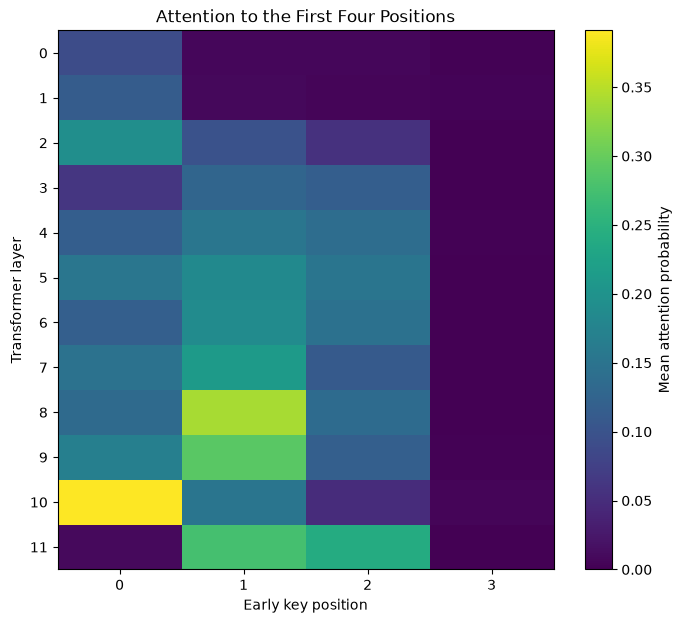

In [11]:
fig, ax = plt.subplots(figsize=(8, 7))

im = ax.imshow(
    scores,
    aspect="auto",
    interpolation="nearest",
)

fig.colorbar(im, ax=ax, label="Mean attention probability")

ax.set_xlabel("Early key position")
ax.set_ylabel("Transformer layer")
ax.set_title("Attention to the First Four Positions")

ax.set_xticks(np.arange(4))
ax.set_xticklabels(EARLY_POSITIONS)
ax.set_yticks(np.arange(L))

plt.show()

## 12. Numerical table for every layer

In [12]:
layer_df = pd.DataFrame({
    "layer": np.arange(L),
    "position_0": scores[:, 0],
    "position_1": scores[:, 1],
    "position_2": scores[:, 2],
    "position_3": scores[:, 3],
})

layer_df["first_4_total"] = (
    layer_df["position_0"]
    + layer_df["position_1"]
    + layer_df["position_2"]
    + layer_df["position_3"]
)

layer_df["position_0_share_of_first4"] = (
    layer_df["position_0"] / layer_df["first_4_total"]
)

display(layer_df)

,layer,position_0,position_1,position_2,position_3,first_4_total,position_0_share_of_first4
0,0,0.090638,0.007065,0.007282,1.906920e-03,0.106892,0.847936
1,1,0.113946,0.008195,0.005123,3.190769e-03,0.130455,0.873454
2,2,0.193461,0.097913,0.055666,1.457340e-03,0.348498,0.555129
3,3,0.061934,0.127471,0.117233,4.980162e-04,0.307136,0.201649
4,4,0.117266,0.154052,0.139299,1.583740e-03,0.412200,0.284487
5,5,0.152787,0.185761,0.152744,6.790119e-04,0.491970,0.310561
6,6,0.118404,0.188789,0.146419,5.024787e-04,0.454115,0.260736
7,7,0.147027,0.213241,0.110344,7.858541e-04,0.471397,0.311895
8,8,0.135657,0.340360,0.136255,1.507607e-03,0.613780,0.221019
9,9,0.169159,0.291061,0.118596,2.241354e-03,0.581056,0.291123


## 13. How dominant is position 0?

We now calculate:

\[
R_l =
\frac{
A(\text{position 0})
}{
A(\text{positions 0,1,2,3})
}
\]

If this ratio is close to 1, most early-token sink attention is concentrated at position 0.

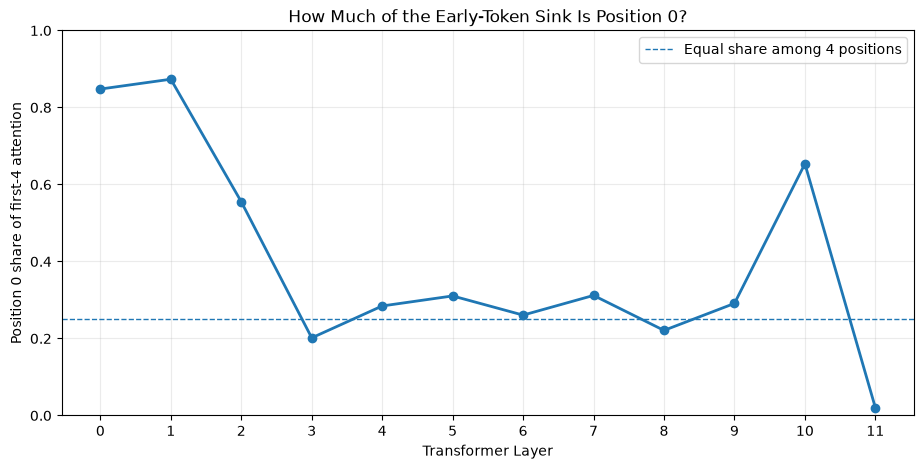

In [13]:
position0_share = layer_df["position_0_share_of_first4"].to_numpy()

plt.figure(figsize=(11, 5))

plt.plot(
    np.arange(L),
    position0_share,
    marker="o",
    linewidth=2
)

plt.axhline(
    0.25,
    linestyle="--",
    linewidth=1,
    label="Equal share among 4 positions"
)

plt.xlabel("Transformer Layer")
plt.ylabel("Position 0 share of first-4 attention")
plt.title("How Much of the Early-Token Sink Is Position 0?")
plt.xticks(np.arange(L))
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## 14. Find which position dominates each layer

In [14]:
dominant_idx = np.argmax(scores, axis=1)
dominant_positions = np.array(EARLY_POSITIONS)[dominant_idx]
dominant_values = scores[np.arange(L), dominant_idx]

dominant_df = pd.DataFrame({
    "layer": np.arange(L),
    "dominant_position": dominant_positions,
    "attention": dominant_values,
})

display(dominant_df)

,layer,dominant_position,attention
0,0,0,0.090638
1,1,0,0.113946
2,2,0,0.193461
3,3,1,0.127471
4,4,1,0.154052
5,5,1,0.185761
6,6,1,0.188789
7,7,1,0.213241
8,8,1,0.340360
9,9,1,0.291061


## 15. Per-head analysis

The previous plots average over all heads.

Now we keep heads separate to see whether individual heads strongly prefer position 0, 1, 2, or 3.

In [15]:
# Average only across later query positions.
# Shape: [layers, heads, 4]
head_position_scores = early_attention.mean(dim=2)

print("Shape:", head_position_scores.shape)

Shape: torch.Size([12, 12, 4])


## 16. Heatmap for position 0: layer × head

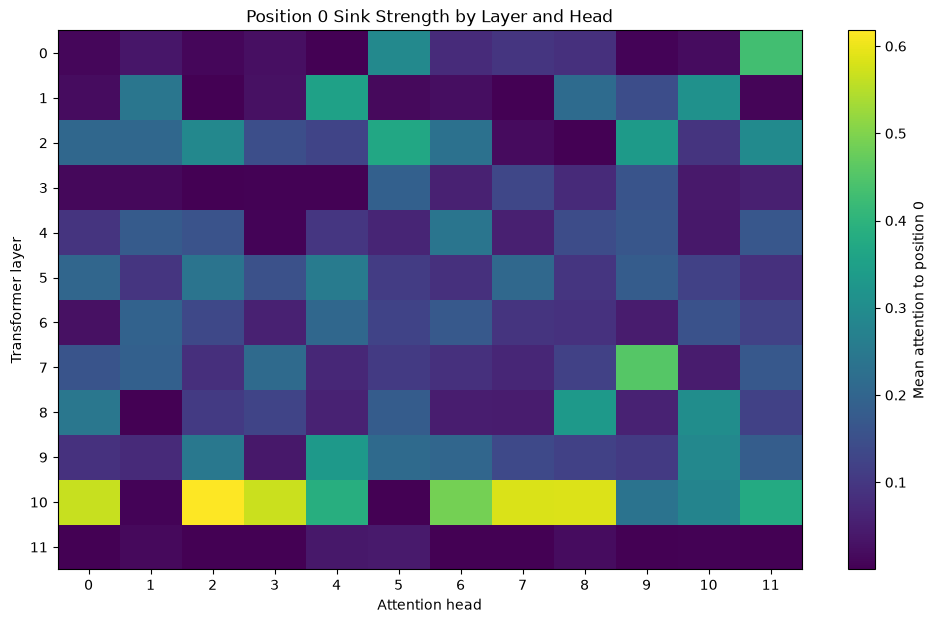

In [16]:
pos0_head_scores = head_position_scores[:, :, 0].numpy()

fig, ax = plt.subplots(figsize=(12, 7))
im = ax.imshow(
    pos0_head_scores,
    aspect="auto",
    interpolation="nearest"
)

fig.colorbar(im, ax=ax, label="Mean attention to position 0")

ax.set_xlabel("Attention head")
ax.set_ylabel("Transformer layer")
ax.set_title("Position 0 Sink Strength by Layer and Head")

ax.set_xticks(np.arange(H))
ax.set_yticks(np.arange(L))

plt.show()

## 17. Compare all four positions per head

For each layer/head pair, determine which of positions 0–3 gets the most attention.

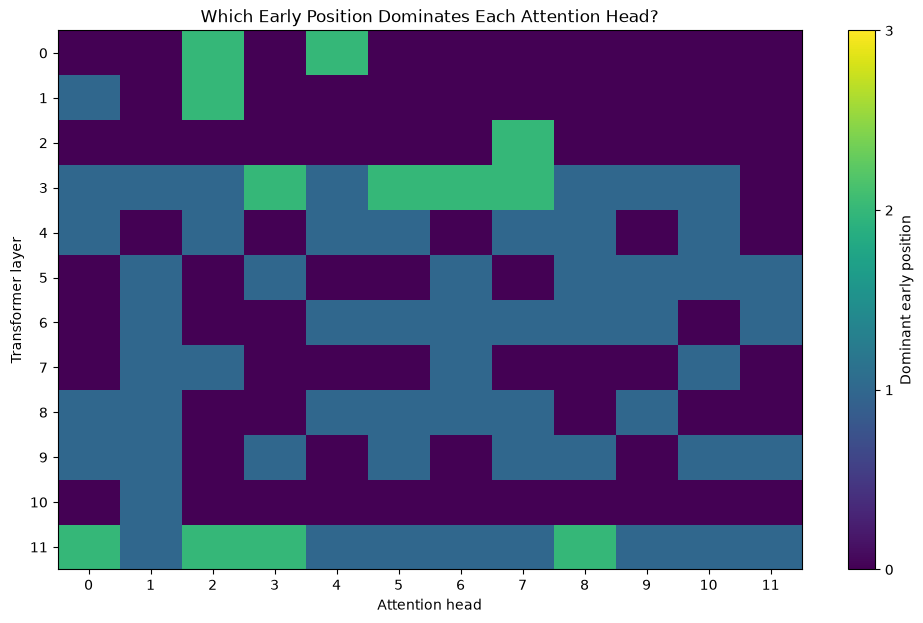

In [17]:
head_scores_np = head_position_scores.numpy()

dominant_early_position = np.argmax(head_scores_np, axis=2)

fig, ax = plt.subplots(figsize=(12, 7))
im = ax.imshow(
    dominant_early_position,
    aspect="auto",
    interpolation="nearest",
    vmin=0,
    vmax=3,
)

cbar = fig.colorbar(im, ax=ax, ticks=[0, 1, 2, 3])
cbar.set_label("Dominant early position")

ax.set_xlabel("Attention head")
ax.set_ylabel("Transformer layer")
ax.set_title("Which Early Position Dominates Each Attention Head?")

ax.set_xticks(np.arange(H))
ax.set_yticks(np.arange(L))

plt.show()

## 18. Rank strongest heads for each position

This lets you see which heads most strongly attend to position 0, 1, 2, and 3.

In [18]:
records = []

for l in range(L):
    for h in range(H):
        row = {
            "layer": l,
            "head": h,
        }

        for idx, pos in enumerate(EARLY_POSITIONS):
            row[f"position_{pos}"] = head_scores_np[l, h, idx]

        records.append(row)

head_df = pd.DataFrame(records)

for pos in EARLY_POSITIONS:
    print(f"\nTop heads for position {pos}")
    display(
        head_df.sort_values(
            f"position_{pos}",
            ascending=False
        ).head(10)
    )


Top heads for position 0


,layer,head,position_0,position_1,position_2,position_3
122,10,2,0.617880,0.152475,0.069303,4.388345e-08
128,10,8,0.586495,0.137227,0.040303,1.411562e-12
127,10,7,0.583251,0.286597,0.035790,1.271380e-17
123,10,3,0.567875,0.313801,0.083429,7.993885e-13
120,10,0,0.565021,0.209600,0.031039,3.891322e-15
126,10,6,0.487882,0.023638,0.002701,6.756250e-15
93,7,9,0.454235,0.217481,0.143339,9.841266e-06
11,0,11,0.429998,0.000047,0.000051,2.902891e-03
124,10,4,0.387025,0.018570,0.003325,1.034425e-25
131,10,11,0.377354,0.179206,0.031479,5.690391e-02



Top heads for position 1


,layer,head,position_0,position_1,position_2,position_3
102,8,6,0.048370,0.753132,0.196940,7.228213e-07
108,9,0,0.088894,0.622980,0.253806,1.551513e-08
90,7,6,0.084947,0.612549,0.221452,6.818919e-06
94,7,10,0.046396,0.609345,0.011546,0.000000e+00
105,8,9,0.059988,0.607982,0.299847,9.069327e-07
119,9,11,0.182783,0.550059,0.266803,8.426481e-07
101,8,5,0.178831,0.547912,0.192182,1.604364e-08
81,6,9,0.046065,0.518678,0.282869,1.630663e-05
97,8,1,0.001793,0.449391,0.077021,2.058169e-09
100,8,4,0.059238,0.437106,0.040792,1.098505e-15



Top heads for position 2


,layer,head,position_0,position_1,position_2,position_3
134,11,2,0.000003,0.224866,0.493483,3.775988e-26
135,11,3,0.000629,0.409211,0.422797,6.786097e-17
132,11,0,0.000083,0.336370,0.349553,4.660330e-16
69,5,9,0.180701,0.405827,0.330958,2.239462e-04
139,11,7,0.000015,0.366631,0.319411,4.943103e-27
105,8,9,0.059988,0.607982,0.299847,9.069327e-07
81,6,9,0.046065,0.518678,0.282869,1.630663e-05
76,6,4,0.205978,0.333273,0.271514,5.586299e-05
119,9,11,0.182783,0.550059,0.266803,8.426481e-07
96,8,0,0.244533,0.369944,0.262555,1.033277e-06



Top heads for position 3


,layer,head,position_0,position_1,position_2,position_3
131,10,11,0.377354,0.179206,0.031479,0.056904
117,9,9,0.105688,0.032227,0.011637,0.017309
98,8,2,0.104983,0.093321,0.034930,0.015482
115,9,7,0.135430,0.168314,0.067317,0.009472
20,1,8,0.215402,0.000450,0.000177,0.007527
7,0,7,0.095601,0.018432,0.018813,0.007381
22,1,10,0.312536,0.009069,0.002839,0.007174
21,1,9,0.146267,0.000352,0.000134,0.007075
31,2,7,0.017493,0.015755,0.024683,0.006799
49,4,1,0.177142,0.120867,0.113368,0.005887


## 19. Strongest position-0 sink head

Automatically find the attention head that gives the most average attention to position 0.

In [19]:
best_flat = np.argmax(pos0_head_scores)
best_layer, best_head = np.unravel_index(
    best_flat,
    pos0_head_scores.shape
)

best_A = attn_stack[best_layer, best_head].numpy()

print("Strongest position-0 head:")
print("Layer:", best_layer)
print("Head:", best_head)
print(
    "Mean attention to position 0:",
    pos0_head_scores[best_layer, best_head]
)

Strongest position-0 head:
Layer: 10
Head: 2
Mean attention to position 0: 0.6178799


## 20. Strongest head: attention to positions 0–3 over query position

This shows whether later tokens continuously attend to position 0 more than positions 1, 2, and 3.

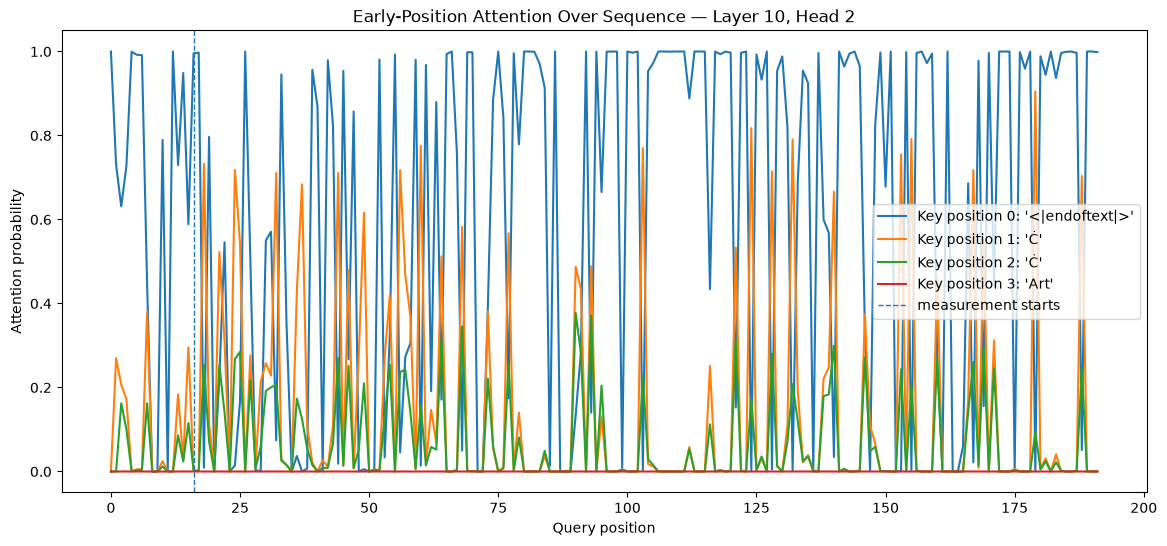

In [20]:
plt.figure(figsize=(14, 6))

for pos in EARLY_POSITIONS:
    plt.plot(
        np.arange(T),
        best_A[:, pos],
        linewidth=1.5,
        label=f"Key position {pos}: {tokens[pos]!r}"
    )

plt.axvline(
    QUERY_START,
    linestyle="--",
    linewidth=1,
    label="measurement starts"
)

plt.xlabel("Query position")
plt.ylabel("Attention probability")
plt.title(
    f"Early-Position Attention Over Sequence — "
    f"Layer {best_layer}, Head {best_head}"
)
plt.legend()
plt.show()

## 21. Strongest head: cumulative attention to positions 0–3

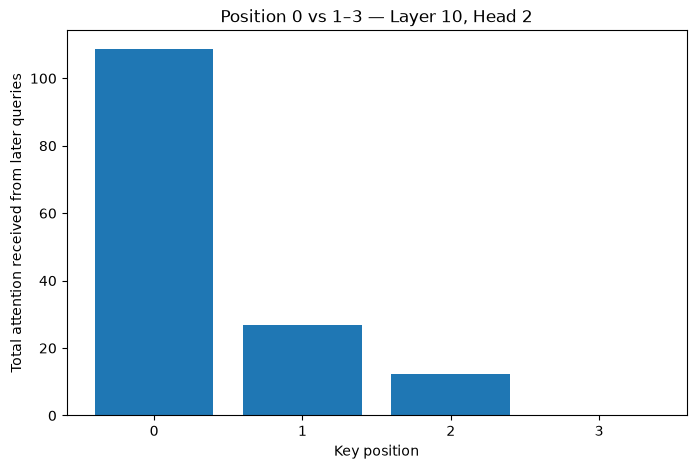

Position 0: 108.7469
Position 1: 26.8356
Position 2: 12.1974
Position 3: 0.0000


In [21]:
totals = np.array([
    best_A[QUERY_START:, pos].sum()
    for pos in EARLY_POSITIONS
])

plt.figure(figsize=(8, 5))
plt.bar(
    [str(p) for p in EARLY_POSITIONS],
    totals
)

plt.xlabel("Key position")
plt.ylabel("Total attention received from later queries")
plt.title(
    f"Position 0 vs 1–3 — Layer {best_layer}, Head {best_head}"
)
plt.show()

for pos, value in zip(EARLY_POSITIONS, totals):
    print(f"Position {pos}: {value:.4f}")

# How to interpret the results

### Case 1 — Position 0 dominates

If you see something like:

```text
Position 0: 0.60
Position 1: 0.03
Position 2: 0.02
Position 3: 0.02
```

then the sink is primarily concentrated at **position 0**.

### Case 2 — Several early positions are large

If you see:

```text
Position 0: 0.25
Position 1: 0.18
Position 2: 0.12
Position 3: 0.10
```

then the model is using a broader **early-token sink region** rather than only one sink token.

### Most important plots

For your analysis, focus on:

1. **Attention to Positions 0, 1, 2, and 3 Across Layers**
2. **How Much of the Early-Token Sink Is Position 0?**
3. **Position 0 Sink Strength by Layer and Head**
4. **Early-Position Attention Over Sequence for the strongest sink head**

These plots let you distinguish a true position-0 sink from a more general first-few-token effect.